In [ ]:
# Run this cell first to install required packages (Colab only)
!pip install "numpy<2" roboticstoolbox-python spatialmath-python -q

# Restart runtime so the new numpy is picked up (required on Colab)
import os, time
if 'COLAB_RELEASE_TAG' in os.environ:
    print('\n\u23f3 Restarting runtime to load numpy<2 \u2014 please re-run all cells after restart.')
    time.sleep(1)
    os.kill(os.getpid(), 9)

# Lab 3: The Geometric Solver
## EE0849 Introduction to Robotics

In this lab you will:
1. Implement analytical inverse kinematics for a 2-link planar arm
2. Visualize workspace boundaries and both elbow configurations
3. Verify IK solutions using forward kinematics
4. Handle edge cases with joint limits filtering
5. Apply IK to path following with smooth solution selection
6. Compare your closed-form solver with `roboticstoolbox` numerical IK

---
## 2-Link IK Review

Given target $(x, y)$ and link lengths $L_1$, $L_2$, find joint angles $\theta_1$, $\theta_2$.

**Step 1 &mdash; Law of cosines:**

$$\cos\theta_2 = \frac{x^2 + y^2 - L_1^2 - L_2^2}{2\,L_1\,L_2}$$

**Step 2 &mdash; Elbow angle:**

- Elbow up: $\sin\theta_2 = +\sqrt{1 - \cos^2\theta_2}$
- Elbow down: $\sin\theta_2 = -\sqrt{1 - \cos^2\theta_2}$

$$\theta_2 = \text{atan2}(\sin\theta_2,\; \cos\theta_2)$$

**Step 3 &mdash; Shoulder angle:**

$$\alpha = \text{atan2}(L_2 \sin\theta_2,\; L_1 + L_2 \cos\theta_2)$$

$$\theta_1 = \text{atan2}(y,\, x) - \alpha$$

### Connection to 6-DOF Robots

This 2-link solver is **not** just a toy example &mdash; it is the core building block for solving real industrial robots.

For a 6-DOF robot with a **spherical wrist** (like the FANUC LR Mate 200iD), the IK problem splits into two independent sub-problems via **kinematic decoupling**:

1. **Position (joints 1-3):** Joint 1 sets the arm plane ($\theta_1 = \text{atan2}(y_{wc}, x_{wc})$), then joints 2-3 are solved as a **2-link IK** in the vertical plane &mdash; exactly the algorithm you will implement below.
2. **Orientation (joints 4-6):** Solved separately via ZYZ Euler angle decomposition of the wrist rotation matrix.

The elbow up/down choice here maps directly to the **U/D flag** in FANUC configuration strings (e.g., `NUT` = No-flip, Up, fronT).

---
## Part 1: Setup & Workspace (15 min)

- Link 1: $L_1 = 1.0$ m, Link 2: $L_2 = 0.5$ m
- Workspace is an annulus: $r_{\min} = |L_1 - L_2|$ to $r_{\max} = L_1 + L_2$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

L1 = 1.0  # meters
L2 = 0.5  # meters


def plot_arm(ax, theta1, theta2, L1, L2, color='steelblue', label=None):
    """Plot a 2-link arm at given configuration."""
    x0, y0 = 0, 0
    x1 = L1 * np.cos(theta1)
    y1 = L1 * np.sin(theta1)
    x2 = x1 + L2 * np.cos(theta1 + theta2)
    y2 = y1 + L2 * np.sin(theta1 + theta2)

    ax.plot([x0, x1], [y0, y1], 'o-', color=color, linewidth=4,
            markersize=10, markerfacecolor='white', markeredgewidth=2)
    ax.plot([x1, x2], [y1, y2], 'o-', color=color, linewidth=4,
            markersize=10, markerfacecolor='white', markeredgewidth=2)
    ax.plot(x2, y2, 's', color=color, markersize=12, label=label)
    return x2, y2


def fk_2link(theta1, theta2, L1, L2):
    """Forward kinematics for 2-link arm.  Returns (x, y)."""
    x = L1 * np.cos(theta1) + L2 * np.cos(theta1 + theta2)
    y = L1 * np.sin(theta1) + L2 * np.sin(theta1 + theta2)
    return x, y


def is_reachable(x, y, L1, L2):
    """Check if point (x, y) is within the workspace annulus."""
    r = np.sqrt(x**2 + y**2)
    return abs(L1 - L2) <= r <= L1 + L2

### Exercise 1: Workspace & Reachability

**Task:** Calculate the workspace boundaries, then test reachability for the five points below.

In [2]:
# YOUR CODE HERE — compute the workspace boundaries
r_max = 0  # replace
r_min = 0  # replace
area  = 0  # replace

print(f"r_max = {r_max:.2f} m")
print(f"r_min = {r_min:.2f} m")
print(f"Workspace area = {area:.4f} m^2")

# Test reachability
test_points = [
    (1.0, 0.5),   # A
    (1.5, 0.0),   # B (on boundary)
    (0.0, 0.0),   # C (origin)
    (2.0, 0.0),   # D (too far)
    (0.3, 0.3),   # E (near inner boundary)
]

print("\nReachability Test:")
print("-" * 45)
for x, y in test_points:
    r = np.sqrt(x**2 + y**2)
    status = "REACHABLE" if is_reachable(x, y, L1, L2) else "UNREACHABLE"
    print(f"({x:4.1f}, {y:4.1f}):  r = {r:.3f} m  ->  {status}")

r_max = 0.00 m
r_min = 0.00 m
Workspace area = 0.0000 m^2

Reachability Test:
---------------------------------------------
( 1.0,  0.5):  r = 1.118 m  ->  REACHABLE
( 1.5,  0.0):  r = 1.500 m  ->  REACHABLE
( 0.0,  0.0):  r = 0.000 m  ->  UNREACHABLE
( 2.0,  0.0):  r = 2.000 m  ->  UNREACHABLE
( 0.3,  0.3):  r = 0.424 m  ->  UNREACHABLE


---
## Part 2: The IK Solver (30 min)

### Exercise 2: Implement `ik_2link`

**Task:** Complete the inverse kinematics function below. Follow the three-step algorithm from the review.

*Hint:* Use `np.arctan2` and `np.sqrt`.

In [3]:
def ik_2link(x, y, L1, L2, elbow='up'):
    """
    Inverse kinematics for 2-link planar arm.

    Parameters:
        x, y: Target position (meters)
        L1, L2: Link lengths (meters)
        elbow: 'up' or 'down' configuration

    Returns:
        theta1, theta2: Joint angles (radians)

    Raises:
        ValueError: If point is unreachable
    """
    # YOUR CODE HERE

    # Step 1: Compute cos(theta2) from the law of cosines
    c2 = 0  # replace

    # Check reachability
    if abs(c2) > 1.0:
        raise ValueError(f"Point ({x}, {y}) unreachable: |cos(theta2)| = {abs(c2):.3f}")

    # Step 2: Compute theta2 (sign of sin selects elbow config)
    theta2 = 0  # replace

    # Step 3: Compute theta1
    theta1 = 0  # replace

    return theta1, theta2

In [4]:
# Verify IK with FK
x_target, y_target = 1.0, 0.5

print(f"Target: ({x_target}, {y_target})")
print("=" * 55)

for elbow in ['up', 'down']:
    theta1, theta2 = ik_2link(x_target, y_target, L1, L2, elbow)
    x_check, y_check = fk_2link(theta1, theta2, L1, L2)
    error = np.sqrt((x_check - x_target)**2 + (y_check - y_target)**2)

    print(f"\n{elbow.upper():5s}:  theta1 = {np.degrees(theta1):7.2f} deg, "
          f" theta2 = {np.degrees(theta2):7.2f} deg")
    print(f"        FK check: ({x_check:.6f}, {y_check:.6f}),  error = {error:.2e} m")

Target: (1.0, 0.5)

UP   :  theta1 =    0.00 deg,  theta2 =    0.00 deg
        FK check: (1.500000, 0.000000),  error = 7.07e-01 m

DOWN :  theta1 =    0.00 deg,  theta2 =    0.00 deg
        FK check: (1.500000, 0.000000),  error = 7.07e-01 m


---
## Part 3: Visualizing Both Solutions (20 min)

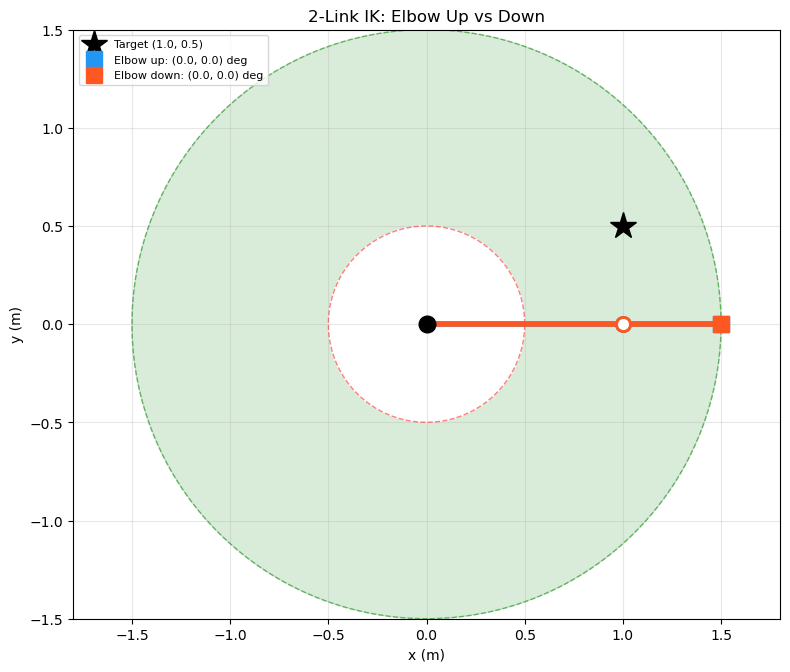

In [5]:
def visualize_ik(x_target, y_target, L1, L2, ax=None):
    """Visualize both elbow configurations for a target point."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 7))

    # Workspace boundaries
    t = np.linspace(0, 2 * np.pi, 200)
    r_max, r_min = L1 + L2, abs(L1 - L2)
    ax.fill(r_max * np.cos(t), r_max * np.sin(t), alpha=0.15, color='green')
    ax.fill(r_min * np.cos(t), r_min * np.sin(t), color='white')
    ax.plot(r_max * np.cos(t), r_max * np.sin(t), 'g--', lw=1, alpha=0.5)
    ax.plot(r_min * np.cos(t), r_min * np.sin(t), 'r--', lw=1, alpha=0.5)

    # Target
    ax.plot(x_target, y_target, 'k*', markersize=20,
            label=f'Target ({x_target}, {y_target})')

    colors = {'up': '#2196F3', 'down': '#FF5722'}
    for elbow in ['up', 'down']:
        try:
            th1, th2 = ik_2link(x_target, y_target, L1, L2, elbow)
            lbl = f'Elbow {elbow}: ({np.degrees(th1):.1f}, {np.degrees(th2):.1f}) deg'
            plot_arm(ax, th1, th2, L1, L2, color=colors[elbow], label=lbl)
        except ValueError as e:
            print(e)

    ax.plot(0, 0, 'ko', markersize=12)
    ax.set_aspect('equal')
    ax.set_xlim(-1.8, 1.8)
    ax.set_ylim(-1.5, 1.5)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    ax.legend(fontsize=8, loc='upper left')
    return ax


visualize_ik(1.0, 0.5, L1, L2)
plt.title('2-Link IK: Elbow Up vs Down')
plt.tight_layout()
plt.show()

### Exercise 3: Multiple Target Points

**Task:** Create a 2×2 subplot showing both IK solutions for each target below.

*Hint:* Call `visualize_ik(x, y, L1, L2, ax=ax)` for each subplot axis.

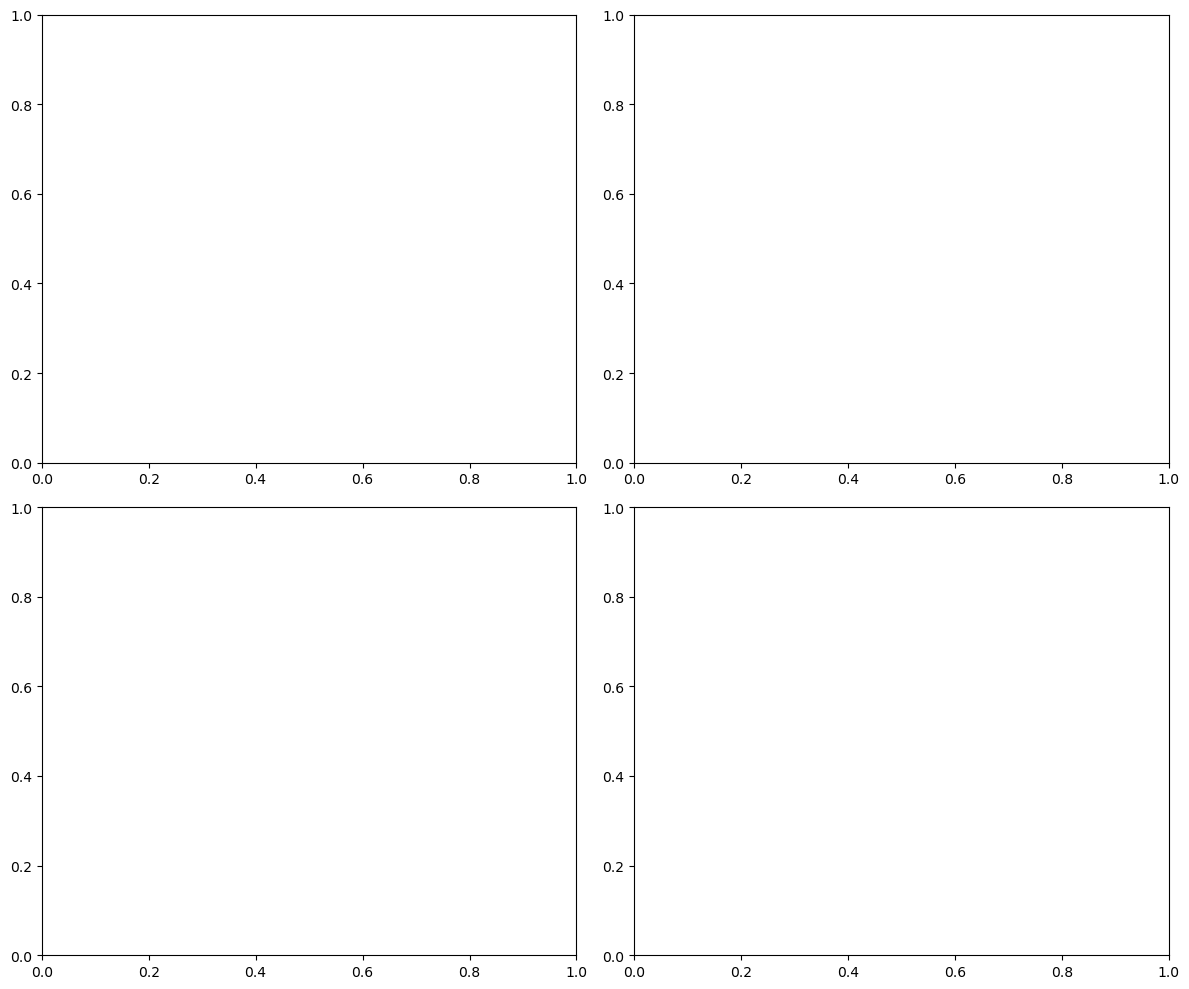

In [6]:
targets = [
    (0.8, 0.8),   # upper region
    (1.2, 0.0),   # on x-axis
    (0.0, 1.0),   # on y-axis
    (-0.5, 0.5),  # second quadrant
]

# YOUR CODE HERE — create a 2x2 subplot figure
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (x, y) in zip(axes.flatten(), targets):
    pass  # replace with visualize_ik call + title

plt.tight_layout()
plt.show()

---
## Part 4: Edge Cases & Singularities (15 min)

At workspace boundaries the two IK solutions merge:

- **Maximum reach** ($r = L_1 + L_2$): arm fully extended, $\theta_2 = 0$
- **Minimum reach** ($r = |L_1 - L_2|$): arm fully folded, $\theta_2 = \pm\pi$

In [7]:
r_max, r_min = L1 + L2, abs(L1 - L2)

cases = [
    (r_max,        0, "Max reach (extended)"),
    (r_min,        0, "Min reach (folded)"),
    (r_max * 0.99, 0, "Near max reach"),
    (r_min * 1.01, 0, "Near min reach"),
]

print("Boundary Case Analysis")
print("=" * 60)
for x, y, desc in cases:
    print(f"\n{desc}: target = ({x:.4f}, {y:.4f})")
    for elbow in ['up', 'down']:
        try:
            th1, th2 = ik_2link(x, y, L1, L2, elbow)
            print(f"  {elbow:5s}: theta1 = {np.degrees(th1):7.2f} deg, "
                  f"theta2 = {np.degrees(th2):7.2f} deg")
        except ValueError as e:
            print(f"  {elbow:5s}: {e}")

Boundary Case Analysis

Max reach (extended): target = (1.5000, 0.0000)
  up   : theta1 =    0.00 deg, theta2 =    0.00 deg
  down : theta1 =    0.00 deg, theta2 =    0.00 deg

Min reach (folded): target = (0.5000, 0.0000)
  up   : theta1 =    0.00 deg, theta2 =    0.00 deg
  down : theta1 =    0.00 deg, theta2 =    0.00 deg

Near max reach: target = (1.4850, 0.0000)
  up   : theta1 =    0.00 deg, theta2 =    0.00 deg
  down : theta1 =    0.00 deg, theta2 =    0.00 deg

Near min reach: target = (0.5050, 0.0000)
  up   : theta1 =    0.00 deg, theta2 =    0.00 deg
  down : theta1 =    0.00 deg, theta2 =    0.00 deg


In [8]:
def ik_2link_safe(x, y, L1, L2, elbow='up', tol=1e-10):
    """IK with numerical clamping for boundary cases."""
    c2 = (x**2 + y**2 - L1**2 - L2**2) / (2 * L1 * L2)

    if c2 > 1.0 and c2 < 1.0 + tol:
        c2 = 1.0
    elif c2 < -1.0 and c2 > -1.0 - tol:
        c2 = -1.0
    elif abs(c2) > 1.0:
        raise ValueError(f"Point unreachable: |cos(theta2)| = {abs(c2):.6f}")

    s2 = np.sqrt(1 - c2**2) if elbow == 'up' else -np.sqrt(1 - c2**2)
    theta2 = np.arctan2(s2, c2)
    alpha = np.arctan2(L2 * s2, L1 + L2 * c2)
    theta1 = np.arctan2(y, x) - alpha
    return theta1, theta2

---
## Part 5: Path Following (20 min)

### Exercise 4: Implement `ik_nearest`

**Task:** Complete the function that returns the IK solution closest to the current joint configuration **and** within joint limits. This prevents large jumps when tracing a path and filters out mechanically infeasible solutions.

*Hint:* Compute joint-space distance $d = \sqrt{(\Delta\theta_1)^2 + (\Delta\theta_2)^2}$ for both elbow solutions, discard any that violate joint limits, and pick the closest remaining one.

In [ ]:
def ik_nearest(x, y, L1, L2, q_current, q_limits=None):
    """
    Return IK solution closest to current configuration, respecting joint limits.

    Parameters:
        x, y: Target position
        L1, L2: Link lengths
        q_current: Current [theta1, theta2]
        q_limits: Optional [(theta1_min, theta1_max), (theta2_min, theta2_max)]
                  in radians. If None, no limits applied.

    Returns:
        theta1, theta2, config ('up' or 'down')
    """
    # YOUR CODE HERE
    solutions = []

    for elbow in ['up', 'down']:
        try:
            theta1, theta2 = ik_2link_safe(x, y, L1, L2, elbow)

            # Check joint limits (if provided)
            if q_limits is not None:
                if not (q_limits[0][0] <= theta1 <= q_limits[0][1]):
                    continue
                if not (q_limits[1][0] <= theta2 <= q_limits[1][1]):
                    continue

            dist = 0  # replace — joint-space distance to q_current
            solutions.append((theta1, theta2, elbow, dist))
        except ValueError:
            pass

    if not solutions:
        raise ValueError("No valid IK solution found (check limits and reachability)")

    # Return closest solution
    solutions.sort(key=lambda s: s[3])
    return solutions[0][0], solutions[0][1], solutions[0][2]

In [ ]:
def trace_circle(cx, cy, radius, L1, L2, n_points=50):
    """Generate joint trajectory for a circular path."""
    angles = np.linspace(0, 2 * np.pi, n_points)
    trajectory, q_current = [], [0.5, 0.5]

    for a in angles:
        x = cx + radius * np.cos(a)
        y = cy + radius * np.sin(a)
        try:
            th1, th2, _ = ik_nearest(x, y, L1, L2, q_current)
            trajectory.append((th1, th2))
            q_current = [th1, th2]
        except ValueError:
            trajectory.append(None)

    return trajectory


# Trace a small circle centred at (0.8, 0.3)
trajectory = trace_circle(0.8, 0.3, 0.2, L1, L2)
valid = sum(1 for t in trajectory if t is not None)
print(f"Generated {valid}/{len(trajectory)} valid waypoints")

### Animating the Path

In [ ]:
from IPython.display import HTML

def animate_path(trajectory, L1, L2):
    """Animate the arm following a trajectory (inline in Jupyter/Colab)."""
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(-1.8, 1.8)
    ax.set_ylim(-1.8, 1.8)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

    # Workspace boundary
    t = np.linspace(0, 2 * np.pi, 200)
    ax.plot((L1 + L2) * np.cos(t), (L1 + L2) * np.sin(t), 'g--', alpha=0.3)
    ax.plot(abs(L1 - L2) * np.cos(t), abs(L1 - L2) * np.sin(t), 'r--', alpha=0.3)

    link1, = ax.plot([], [], 'o-', color='steelblue', lw=4, markersize=10,
                     markerfacecolor='white', markeredgewidth=2)
    link2, = ax.plot([], [], 'o-', color='steelblue', lw=4, markersize=10,
                     markerfacecolor='white', markeredgewidth=2)
    ee_marker, = ax.plot([], [], 's', color='orange', markersize=12)
    ee_trail, = ax.plot([], [], '-', color='orange', lw=1, alpha=0.5)
    history = []

    def update(frame):
        if trajectory[frame] is None:
            return link1, link2, ee_marker, ee_trail
        th1, th2 = trajectory[frame]
        x1 = L1 * np.cos(th1)
        y1 = L1 * np.sin(th1)
        x2 = x1 + L2 * np.cos(th1 + th2)
        y2 = y1 + L2 * np.sin(th1 + th2)
        link1.set_data([0, x1], [0, y1])
        link2.set_data([x1, x2], [y1, y2])
        ee_marker.set_data([x2], [y2])
        history.append((x2, y2))
        ee_trail.set_data(*zip(*history))
        return link1, link2, ee_marker, ee_trail

    ani = FuncAnimation(fig, update, frames=len(trajectory),
                        blit=True, interval=80)
    plt.close()
    return HTML(ani.to_jshtml())


animate_path(trajectory, L1, L2)

### Exercise 5: Custom Path

**Task:** Design your own path (square, figure-8, line, spiral, etc.) and animate the arm following it.

In [ ]:
def custom_path(n_points=80):
    """Generate (x, y) waypoints for a custom path."""
    # YOUR CODE HERE — return a list of (x, y) tuples
    t = np.linspace(0, 2 * np.pi, n_points)
    path = [(0.8, 0.3)] * n_points  # replace with your path
    return path


# Solve IK along the path
path = custom_path()
traj, q = [], [0.5, 0.5]
for x, y in path:
    try:
        th1, th2, _ = ik_nearest(x, y, L1, L2, q)
        traj.append((th1, th2))
        q = [th1, th2]
    except ValueError:
        traj.append(None)

animate_path(traj, L1, L2)

---
## Part 6: Comparison with roboticstoolbox (10 min)

In the lecture we saw that `roboticstoolbox` provides built-in IK solvers. Let's compare our hand-written geometric solver with the library's **numerical** solver (`ikine_LM` — Levenberg-Marquardt) on the same 2-link arm.

**Key differences:**
- Our solver is **closed-form**: instant, deterministic, gives both solutions
- `ikine_LM` is **numerical**: iterative, needs an initial guess, finds one solution per run
- For robots with a spherical wrist, prefer `ikine_a()` (analytical) when available

In [ ]:
from roboticstoolbox import DHRobot, RevoluteDH
from spatialmath import SE3
import time

# Build the same 2-link arm in roboticstoolbox
robot = DHRobot([
    RevoluteDH(d=0, a=L1, alpha=0),
    RevoluteDH(d=0, a=L2, alpha=0),
], name='2-Link')

print(robot)
print()

# Target point
x_target, y_target = 1.0, 0.5
T_target = SE3.Trans(x_target, y_target, 0)

# --- Our geometric solver ---
t0 = time.perf_counter()
for _ in range(1000):
    th1_geo, th2_geo = ik_2link(x_target, y_target, L1, L2, 'up')
t_geo = (time.perf_counter() - t0) / 1000

# --- RTB numerical solver ---
# mask=[1,1,0,0,0,0] tells the solver to match only x,y translation
# (ignore z, roll, pitch, yaw — our 2-DOF arm can't control those)
t0 = time.perf_counter()
sol = robot.ikine_LM(T_target, q0=[0.5, 0.5], mask=[1, 1, 0, 0, 0, 0])
t_rtb = time.perf_counter() - t0

print("=" * 60)
print(f"Target: ({x_target}, {y_target})")
print()
print(f"Geometric (ours):  theta1 = {np.degrees(th1_geo):7.2f} deg, "
      f"theta2 = {np.degrees(th2_geo):7.2f} deg")
print(f"  Time per solve: {t_geo*1e6:.1f} µs")
print()
print(f"RTB ikine_LM:      theta1 = {np.degrees(sol.q[0]):7.2f} deg, "
      f"theta2 = {np.degrees(sol.q[1]):7.2f} deg")
print(f"  Converged: {sol.success},  Time: {t_rtb*1e3:.1f} ms")
print()

# FK verification for both
x1, y1 = fk_2link(th1_geo, th2_geo, L1, L2)
x2, y2 = fk_2link(sol.q[0], sol.q[1], L1, L2)
print(f"FK check (geometric): ({x1:.6f}, {y1:.6f})")
print(f"FK check (RTB):       ({x2:.6f}, {y2:.6f})")